In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("sigiriya_synthetic_visitors_2023_2025.csv")

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date')

df.head()


,Date,Attraction,Avg_Temperature,Rainfall_mm,Public_Holiday_Count,Festival_Season,Foreign_Visitors_%,Visitor_Count
0,2023-01-01,Sigiriya Rock Fortress,26.5,7.4,1,New Year,68,5185
1,2023-01-02,Sigiriya Rock Fortress,25.7,1.1,0,Peak Season,67,3897
2,2023-01-03,Sigiriya Rock Fortress,26.8,8.6,0,Peak Season,70,3338
3,2023-01-04,Sigiriya Rock Fortress,26.9,11.8,0,Peak Season,68,3507
4,2023-01-05,Sigiriya Rock Fortress,25.2,14.1,0,Peak Season,67,3472


In [3]:
prophet_df = df.rename(columns={
    "Date": "ds",
    "Visitor_Count": "y"
})

In [4]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Add regressors
model.add_regressor('Avg_Temperature')
model.add_regressor('Rainfall_mm')
model.add_regressor('Public_Holiday_Count')
model.add_regressor('Foreign_Visitors_%')


c:\Projects 2026\TourismDigitalFC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [5]:
model.fit(prophet_df)

00:51:37 - cmdstanpy - INFO - Chain [1] start processing
00:51:37 - cmdstanpy - INFO - Chain [1] done processing


In [6]:
future = model.make_future_dataframe(periods=90)  # 90-day forecast

# Forward-fill regressor values (or replace with forecasted weather)
for col in ['Avg_Temperature', 'Rainfall_mm', 'Public_Holiday_Count', 'Foreign_Visitors_%']:
    future[col] = prophet_df[col].iloc[-1]


In [7]:
forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1170,2026-03-16,2452.605601,2118.805176,2812.152968
1171,2026-03-17,2423.316055,2083.937062,2755.376814
1172,2026-03-18,2450.985698,2117.372421,2792.601189
1173,2026-03-19,2412.006324,2089.167361,2768.479980
1174,2026-03-20,2428.496682,2083.030139,2741.869674


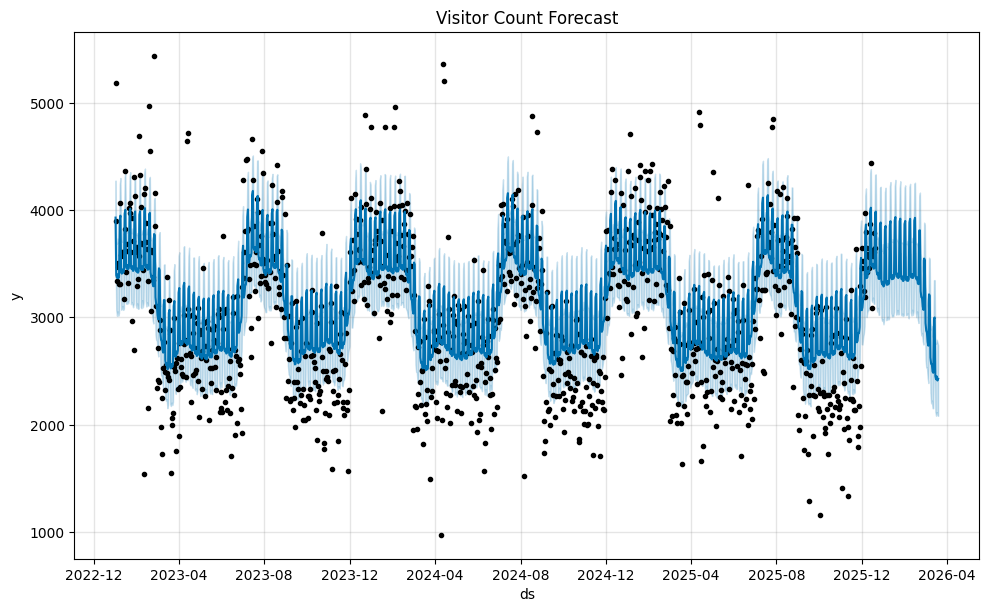

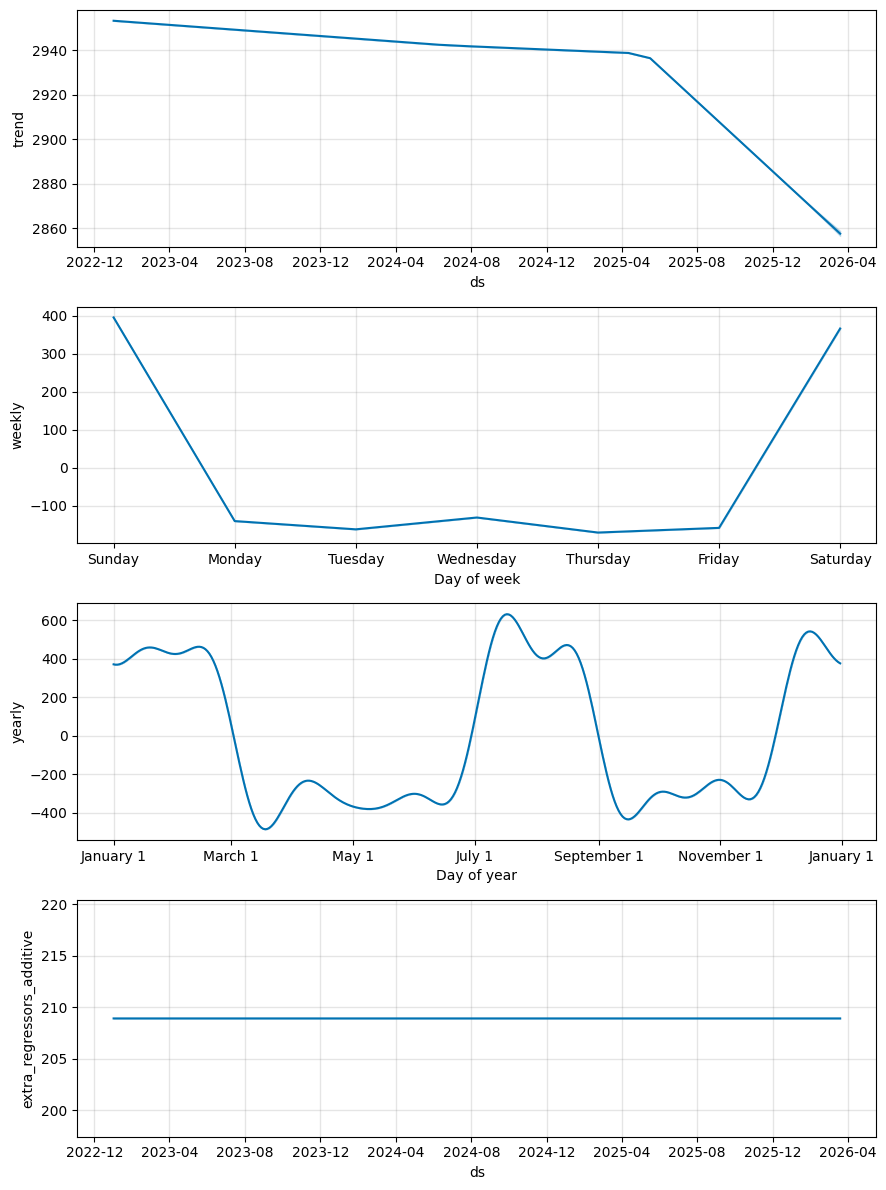

In [8]:
import matplotlib.pyplot as plt

model.plot(forecast)
plt.title("Visitor Count Forecast")
plt.show()

model.plot_components(forecast)
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error

actual = prophet_df['y'][-30:]
predicted = forecast['yhat'][-30:]

mae = mean_absolute_error(actual, predicted)
print("MAE:", mae) 

MAE: 892.5079092694622


In [10]:
import numpy as np

# Actual & Predicted
actual = prophet_df['y'][-30:].values
predicted = forecast['yhat'][-30:].values

# Avoid division by zero
mask = actual != 0

mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

print(f"MAE  : {mae:.2f}")
print(f"MAPE : {mape:.2f}%")


MAE  : 892.51
MAPE : 30.42%


In [11]:
accuracy = 100 - mape
print(f"Forecast Accuracy ≈ {accuracy:.2f}%")

Forecast Accuracy ≈ 69.58%
